In [1]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torchsummary import summary
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import json
import os
from torchvision.transforms import InterpolationMode
import matplotlib.pyplot as plt
import numpy as np
import random
import sys
import time
import h5py

In [ ]:

import warnings
warnings.filterwarnings('ignore')

os.environ["WANDB_DISABLED"] = "true"

In [3]:
# GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [4]:
class Food101Dataset(Dataset):
    def __init__(self, json_path, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
    
        # Load and process the JSON file
        with open(json_path) as f:
            data = json.load(f)
        
        self.image_paths = []
        self.labels = []
        self.class_to_idx = {cls_name: idx for idx, cls_name in enumerate(data.keys())}
        
        for cls_name, images in data.items():
            cls_idx = self.class_to_idx[cls_name]
            for img_path in images:
                self.image_paths.append(img_path)
                self.labels.append(cls_idx)
    
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        img_path = os.path.join(self.root_dir, 'images', f"{self.image_paths[idx]}.jpg")
        image = Image.open(img_path).convert('RGB')
        label = self.labels[idx]
        
        if self.transform:
            image = self.transform(image)
            
        return image, label

In [5]:
root_dir = "/kaggle/input/datasets/kmader/food41"  
train_json = os.path.join(root_dir, "meta", "meta", "train.json")
test_json = os.path.join(root_dir, "meta", "meta", "test.json")

In [6]:
test_transform = transforms.Compose([
    transforms.Resize((320, 320), interpolation=InterpolationMode.BILINEAR),
    transforms.CenterCrop(288),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                        std=[0.229, 0.224, 0.225])
])


test_dataset = Food101Dataset(
    json_path=test_json,
    root_dir=root_dir,
    transform=test_transform
)

batch_size = 128

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
)


In [7]:
def load_model():
    # 1. Inițializăm arhitectura de bază
    model = torchvision.models.efficientnet_b2()
    num_features = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(num_features, 101)

    
    # model = torchvision.models.mobilenet_v2()
    # num_features = model.classifier[1].in_features
    # model.classifier[1] = nn.Linear(num_features, 101)

    
    # model = torchvision.models.densenet121()
    # num_features = model.classifier.in_features
    # model.classifier = nn.Linear(num_features, 101)

    
    # model = torchvision.models.resnet50()
    # num_features = model.fc.in_features
    # model.fc = nn.Linear(num_features, 101)

    resnet_path = '/kaggle/input/models/iliaalexandru/efficientnet-b2-food101-best-v2/pytorch/default/5/resnet_50_food101_best.pth'
    efficientnet_path = '/kaggle/input/models/iliaalexandru/efficientnet-b2-food101-best-v2/pytorch/default/5/efficientnet_b2_food101_best (2).pth'
    mobilenet_path = '/kaggle/input/models/iliaalexandru/efficientnet-b2-food101-best-v2/pytorch/default/5/mobilenet_v2_food101_best.pth'
    densenet_path = '/kaggle/input/models/iliaalexandru/efficientnet-b2-food101-best-v2/pytorch/default/5/densenet_121_food101_best.pth'
    
    
    # 3. Încărcăm starea salvată (cel mai bun model)
    checkpoint = torch.load(
        efficientnet_path,
        map_location=torch.device('cpu')
    )
    model.load_state_dict(checkpoint['model_state_dict'])
    idx_to_class = checkpoint['idx_to_class']
    
    model = model.to(device)
    model.eval()
    
    return model, idx_to_class

In [8]:
import seaborn as sns

def plot_confusion_analysis(all_labels, all_predictions, idx_to_class):
    # 1. Calculăm matricea de confuzie
    cm = confusion_matrix(all_labels, all_predictions)
    class_names = [idx_to_class[i] for i in range(len(idx_to_class))]
    
   
    plt.figure(figsize=(24, 20))
    # 'viridis' sau 'Blues' sunt culori bune. Folosim fmt='d' pentru a printa numere întregi
    sns.heatmap(cm, annot=False, cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix', fontsize=20)
    plt.ylabel('Clasa Adevarata', fontsize=16)
    plt.xlabel('Clasa Prezisa', fontsize=16)
    
    # Rotim textul ca sa se poata citi (dacă sunt prea multe)
    plt.xticks(rotation=90, fontsize=8)
    plt.yticks(rotation=0, fontsize=8)
    
    plt.tight_layout()
    plt.savefig('/kaggle/working/confusion_matrix_full.png', dpi=300)
    plt.show()


    print("\n" + "="*50)
    print("TOP 15 CELE MAI FRECVENTE CONFUZII")
    print("="*50)
    
    # Ștergem diagonala (pentru că diagonala înseamnă predicții corecte)
    np.fill_diagonal(cm, 0)
    
    confusions = []
    # Parcurgem toate combinațiile posibile
    for i in range(len(class_names)):
        for j in range(len(class_names)):
            if cm[i, j] > 0:
                confusions.append({
                    'real': class_names[i],
                    'predicted': class_names[j],
                    'count': cm[i, j]
                })
    
    # Sortăm descrescător după numărul de greșeli
    confusions.sort(key=lambda x: x['count'], reverse=True)
    
    # Afișăm top 15
    for k, error in enumerate(confusions[:15]):
        print(f"{k+1:2d}. Era de fapt [{error['real'].upper()}] " 
              f"dar modelul a zis [{error['predicted'].upper()}] - de {error['count']} ori")

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd

def eval_model():
    model, idx_to_class = load_model()

    all_predictions = []
    all_labels = []

    with torch.no_grad():
        for i, (batch_tensors, batch_labels) in enumerate(test_loader):
                batch_tensors = batch_tensors.to(device)
                
                outputs = model(batch_tensors)
                _, predicted = torch.max(outputs.data, 1)
                
                all_predictions.extend(predicted.cpu().numpy())
                all_labels.extend(batch_labels.numpy())
                
                if i % 10 == 0:
                    evaluate_count = min((i + 1) * batch_size, len(test_dataset))
                    print(f"Procesat {evaluate_count} / {len(test_dataset)} imagini...", end='\r')

    class_names = [idx_to_class[i] for i in range(len(idx_to_class))]
    report_dict = classification_report(
        all_labels, 
        all_predictions, 
        target_names=class_names,

        output_dict=True
    )
  
    df_report = pd.DataFrame(report_dict).transpose().round(4)
    


    df_classes = df_report.iloc[:-3]   
    df_summary = df_report.iloc[-3:]

   
    df_classes_sorted = df_classes.sort_values(by='f1-score', ascending=False)

  
    df_final = pd.concat([df_classes_sorted, df_summary])


    excel_path = '/kaggle/working/raport_MobileNet-V2.xlsx'
    df_final.to_excel(excel_path, index=True)

    cm = confusion_matrix(all_labels, all_predictions)
    per_class_accuracy = cm.diagonal() / cm.sum(axis=1)
    
    class_accuracies = list(zip(class_names, per_class_accuracy))
    class_accuracies.sort(key=lambda x: x[1], reverse=True)
    
    print("\nTop 10 Best Performing Classes:")
    for class_name, accuracy in class_accuracies[:10]:
        print(f"{class_name}: {accuracy:.3f}")
    
    print("\nTop 10 Worst Performing Classes:")
    for class_name, accuracy in class_accuracies[-10:]:
        print(f"{class_name}: {accuracy:.3f}")

    return all_labels, all_predictions, idx_to_class
    

In [10]:
all_labels, all_predictions, idx_to_class = eval_model()

Procesat 24448 / 25250 imagini...
Top 10 Best Performing Classes:
edamame: 0.996
macarons: 0.976
pad_thai: 0.968
takoyaki: 0.964
seaweed_salad: 0.964
spaghetti_bolognese: 0.960
deviled_eggs: 0.960
hot_and_sour_soup: 0.956
french_fries: 0.952
pizza: 0.952

Top 10 Worst Performing Classes:
cheesecake: 0.728
huevos_rancheros: 0.720
ravioli: 0.716
apple_pie: 0.700
bread_pudding: 0.700
foie_gras: 0.696
chocolate_mousse: 0.696
tuna_tartare: 0.692
pork_chop: 0.688
steak: 0.620


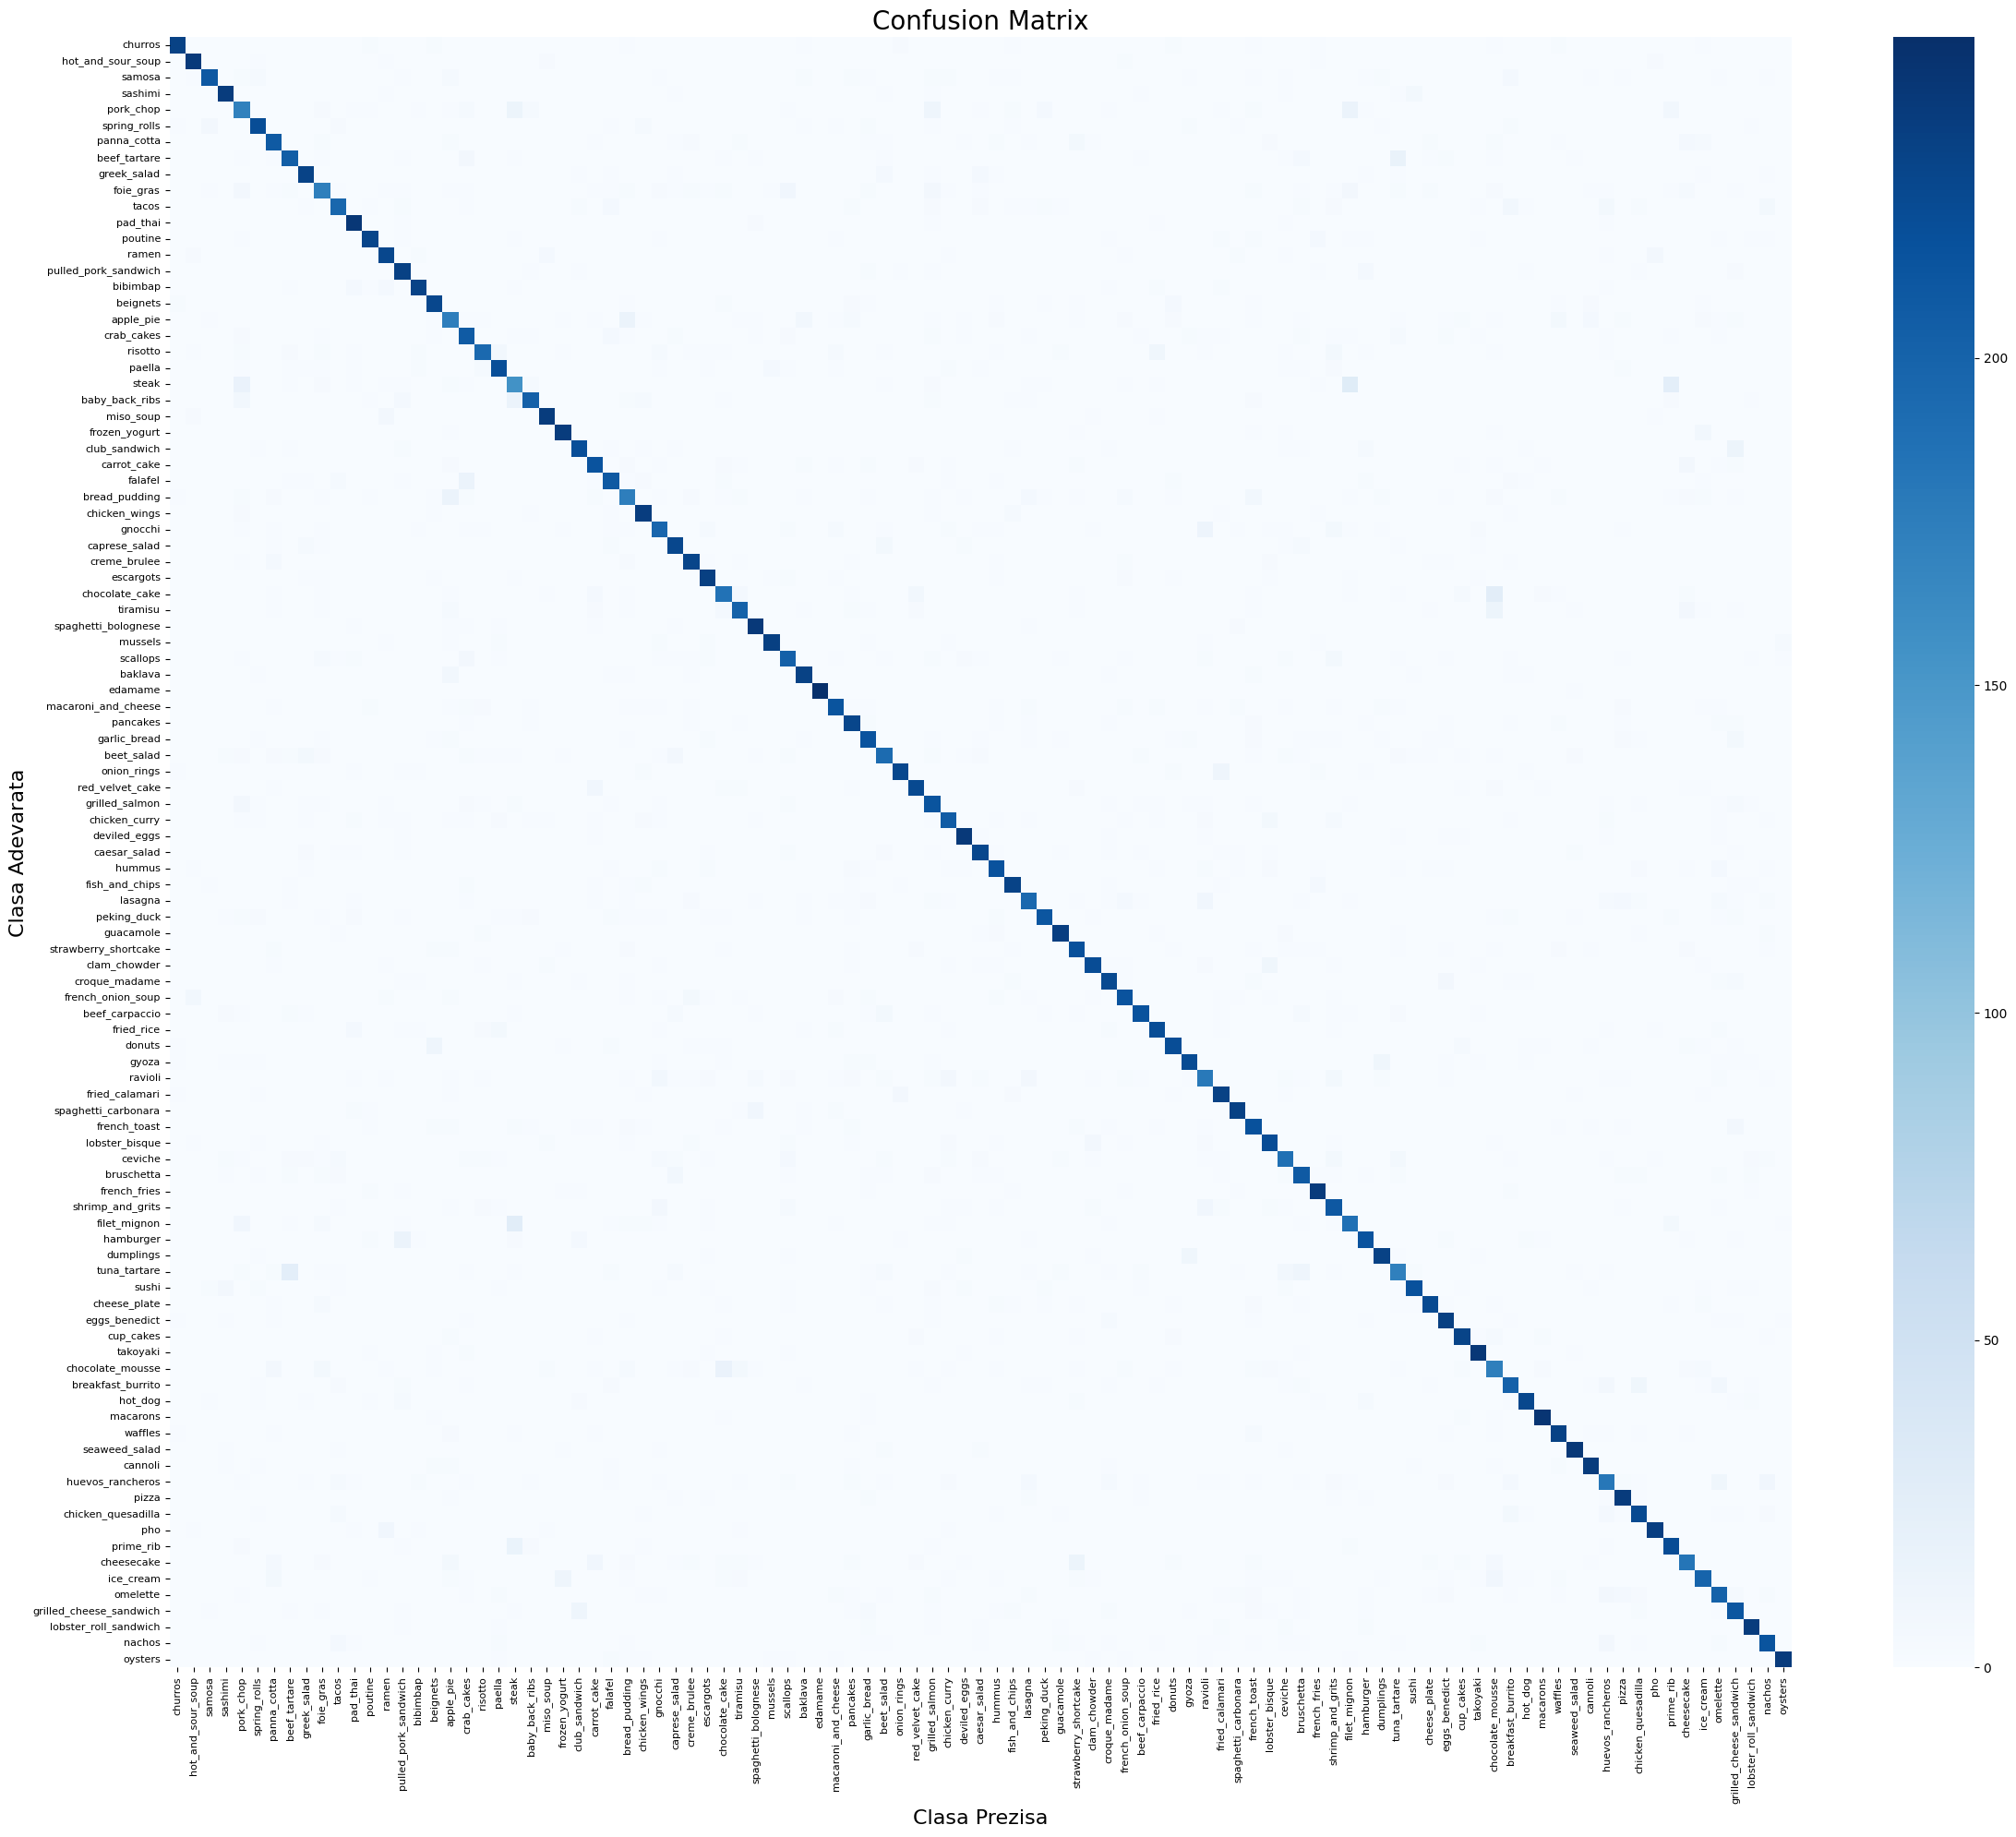


TOP 15 CELE MAI FRECVENTE CONFUZII
 1. Era de fapt [STEAK] dar modelul a zis [FILET_MIGNON] - de 30 ori
 2. Era de fapt [FILET_MIGNON] dar modelul a zis [STEAK] - de 28 ori
 3. Era de fapt [CHOCOLATE_CAKE] dar modelul a zis [CHOCOLATE_MOUSSE] - de 27 ori
 4. Era de fapt [STEAK] dar modelul a zis [PRIME_RIB] - de 25 ori
 5. Era de fapt [TUNA_TARTARE] dar modelul a zis [BEEF_TARTARE] - de 25 ori
 6. Era de fapt [BEEF_TARTARE] dar modelul a zis [TUNA_TARTARE] - de 18 ori
 7. Era de fapt [STEAK] dar modelul a zis [PORK_CHOP] - de 17 ori
 8. Era de fapt [CHOCOLATE_MOUSSE] dar modelul a zis [CHOCOLATE_CAKE] - de 17 ori
 9. Era de fapt [PRIME_RIB] dar modelul a zis [STEAK] - de 16 ori
10. Era de fapt [PORK_CHOP] dar modelul a zis [FILET_MIGNON] - de 15 ori
11. Era de fapt [APPLE_PIE] dar modelul a zis [BREAD_PUDDING] - de 15 ori
12. Era de fapt [BABY_BACK_RIBS] dar modelul a zis [STEAK] - de 15 ori
13. Era de fapt [FALAFEL] dar modelul a zis [CRAB_CAKES] - de 15 ori
14. Era de fapt [BREAD_PU

In [ ]:
plot_confusion_analysis(all_labels, all_predictions, idx_to_class)

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

def plot_top_matrix_with_percentages(all_labels, all_predictions, idx_to_class, top_n=10):

    cm = confusion_matrix(all_labels, all_predictions)
    

    row_sums = cm.sum(axis=1) 
    

    cm_errors = cm.copy()
    np.fill_diagonal(cm_errors, 0)
    

    flat_indices = np.argsort(cm_errors, axis=None)[::-1]
    top_indices = np.unravel_index(flat_indices[:top_n], cm_errors.shape)

    unique_classes = np.unique(np.concatenate((top_indices[0], top_indices[1])))
    

    sub_cm = cm[np.ix_(unique_classes, unique_classes)]
    

    annot_matrix = np.empty(sub_cm.shape, dtype=object)
    
    for i, row_idx in enumerate(unique_classes):
        for j, col_idx in enumerate(unique_classes):
            count = sub_cm[i, j]
    
            pct = (count / row_sums[row_idx]) * 100 if row_sums[row_idx] > 0 else 0
            
          
            annot_matrix[i, j] = f"{count}\n({pct:.1f}%)"

    class_names = [idx_to_class[idx] for idx in unique_classes]
    df_cm = pd.DataFrame(sub_cm, index=class_names, columns=class_names)
    
  
    plt.figure(figsize=(14, 11))

    ax = sns.heatmap(df_cm, annot=annot_matrix, fmt='', cmap='Greens', linewidths=.5,
                     # cbar_kws={'label': 'Număr absolut de predicții'},
                     annot_kws={"size": 12, "weight": "bold"})

    plt.title(f'Matricea de Confuzie Trunchiată (Clasele implicate Top {top_n} Erori)\nEfficientNet-B2\n', 
              fontsize=15, weight='bold')
    plt.ylabel('Clasa Reală', fontsize=12, weight='bold')
    plt.xlabel('Clasa Prezisă', fontsize=12, weight='bold')
    
    plt.xticks(rotation=45, ha='right', fontsize=11)
    plt.yticks(rotation=0, fontsize=11)
    plt.tight_layout()
    
    # Salvăm imaginea
    plt.savefig('matrice_confuzie_EfficientNet-B2.png', dpi=300)
    print("\n -> Matricea trunchiată COMPLETĂ (cu tot cu predicțiile corecte) a fost generată și salvată!")
    plt.show()


 -> Matricea trunchiată COMPLETĂ (cu tot cu predicțiile corecte) a fost generată și salvată!


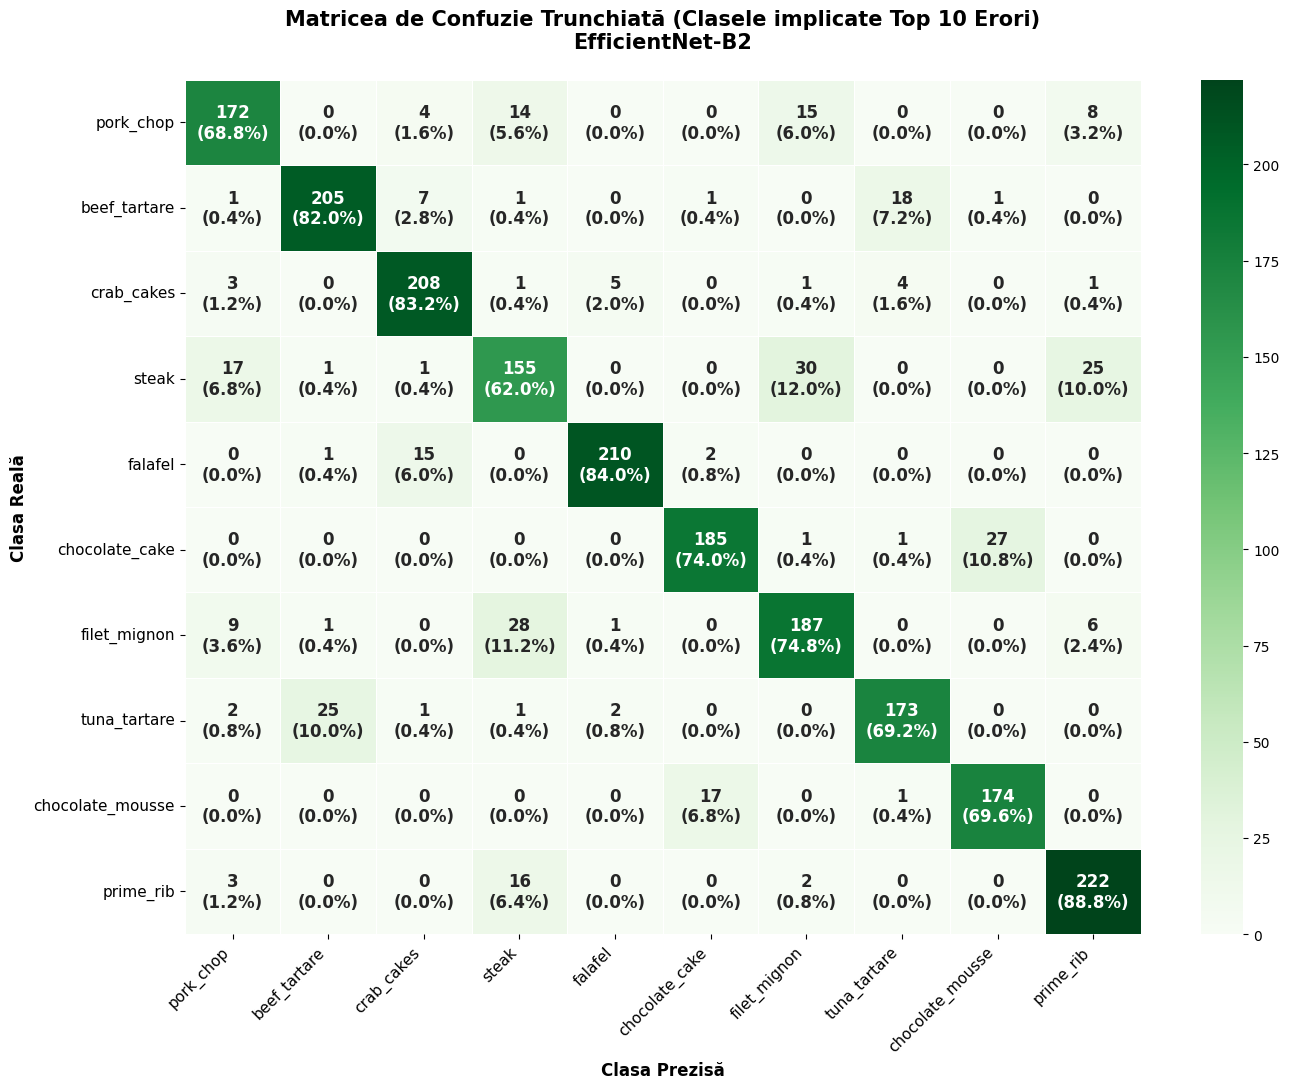

In [13]:
plot_top_matrix_with_percentages(all_labels, all_predictions, idx_to_class)